<a href="https://colab.research.google.com/github/samikshak02/Python-Basic-Projects./blob/master/Task19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#	Dataset Selection & Initial Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded= files.upload()
filepath="/content/laptop_data.csv"
df=pd.read_csv(filepath)

Saving laptop_data.csv to laptop_data.csv


In [3]:
df

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080
...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.6400
1299,1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.7200
1300,1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.1200
1301,1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.9200


In [4]:
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


# Missing & Duplicate Values Analysis

In [9]:
# Missing values
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

print("Missing Values:")
print(missing)

print("\nMissing Percentage:")
print(missing_percent)

Missing Values:
Unnamed: 0          0
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

Missing Percentage:
Unnamed: 0          0.0
Company             0.0
TypeName            0.0
Inches              0.0
ScreenResolution    0.0
Cpu                 0.0
Ram                 0.0
Memory              0.0
Gpu                 0.0
OpSys               0.0
Weight              0.0
Price               0.0
dtype: float64


In [6]:
# Handle missing values
df = df.dropna()


In [7]:
# Duplicate values
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [8]:
# Remove duplicates
df = df.drop_duplicates()

# Statistical Summary

In [11]:
print(df.describe())

       Unnamed: 0       Inches          Price
count  1303.00000  1303.000000    1303.000000
mean    651.00000    15.017191   59870.042910
std     376.28801     1.426304   37243.201786
min       0.00000    10.100000    9270.720000
25%     325.50000    14.000000   31914.720000
50%     651.00000    15.600000   52054.560000
75%     976.50000    15.600000   79274.246400
max    1302.00000    18.400000  324954.720000


In [12]:
print("Minimum Price:", df["Price"].min())
print("Maximum Price:", df["Price"].max())
print("Mean Price:", df["Price"].mean())
print("Median Price:", df["Price"].median())

Minimum Price: 9270.72
Maximum Price: 324954.72
Mean Price: 59870.042910207216
Median Price: 52054.56


#	Histogram Analysis of Numeric Features

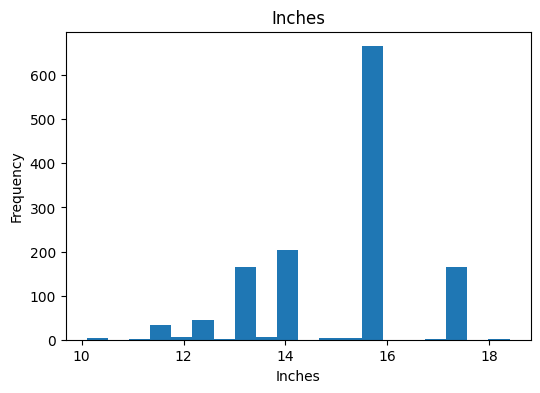

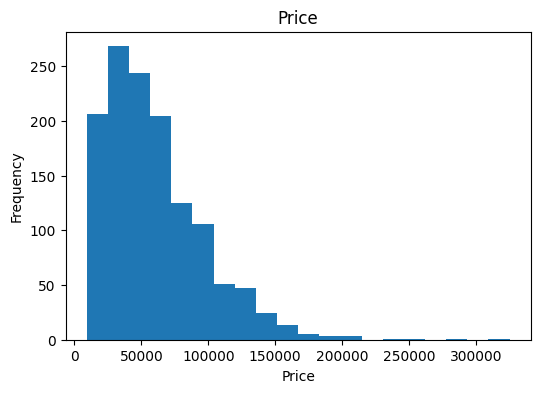

In [20]:
numeric_cols = ["Inches", "Price"]

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=20)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# Count Plots of Categorical Features

In [24]:
# Identify categorical columns
cat_cols = df.select_dtypes(include='object').columns
print(cat_cols)

Index(['Company', 'TypeName', 'ScreenResolution', 'Cpu', 'Ram', 'Memory',
       'Gpu', 'OpSys', 'Weight'],
      dtype='object')


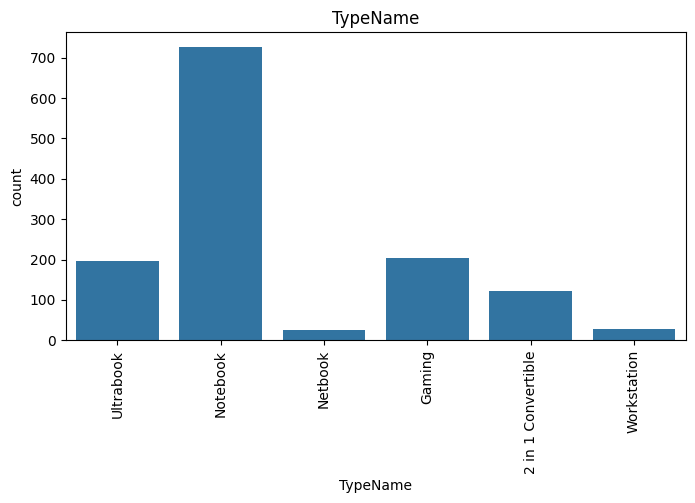

In [50]:
plt.figure(figsize=(8,4))
sns.countplot(x="TypeName", data=df)
plt.title("TypeName")
plt.xticks(rotation=90)
plt.show()

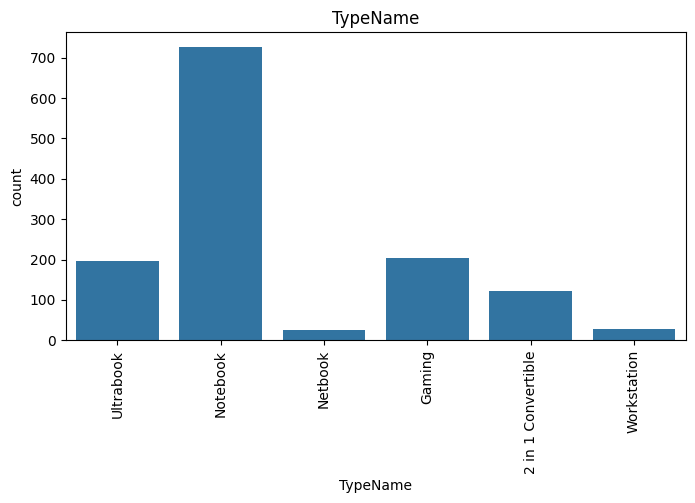

In [28]:
plt.figure(figsize=(8,4))
sns.countplot(x="TypeName", data=df)
plt.title("TypeName")
plt.xticks(rotation=90)
plt.show()

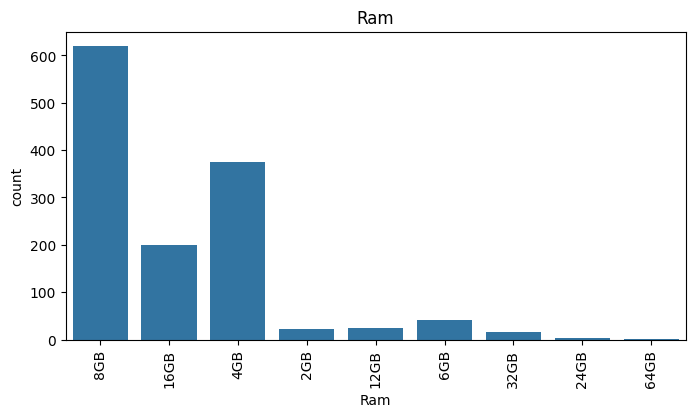

In [29]:
plt.figure(figsize=(8,4))
sns.countplot(x="Ram", data=df)
plt.title("Ram")
plt.xticks(rotation=90)
plt.show()

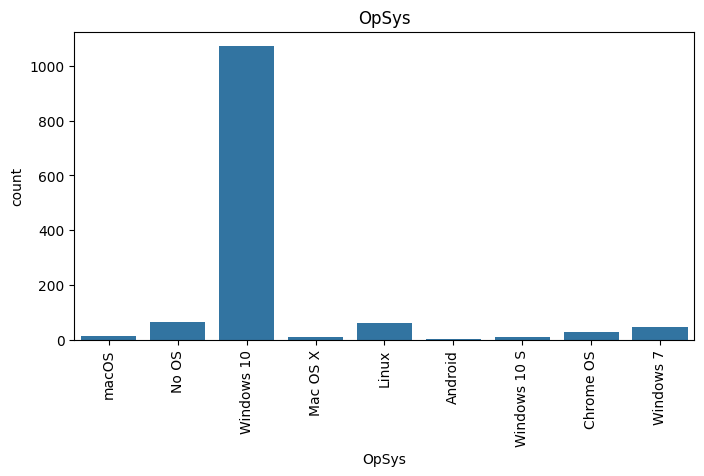

In [31]:
plt.figure(figsize=(8,4))
sns.countplot(x="OpSys", data=df)
plt.title("OpSys")
plt.xticks(rotation=90)
plt.show()

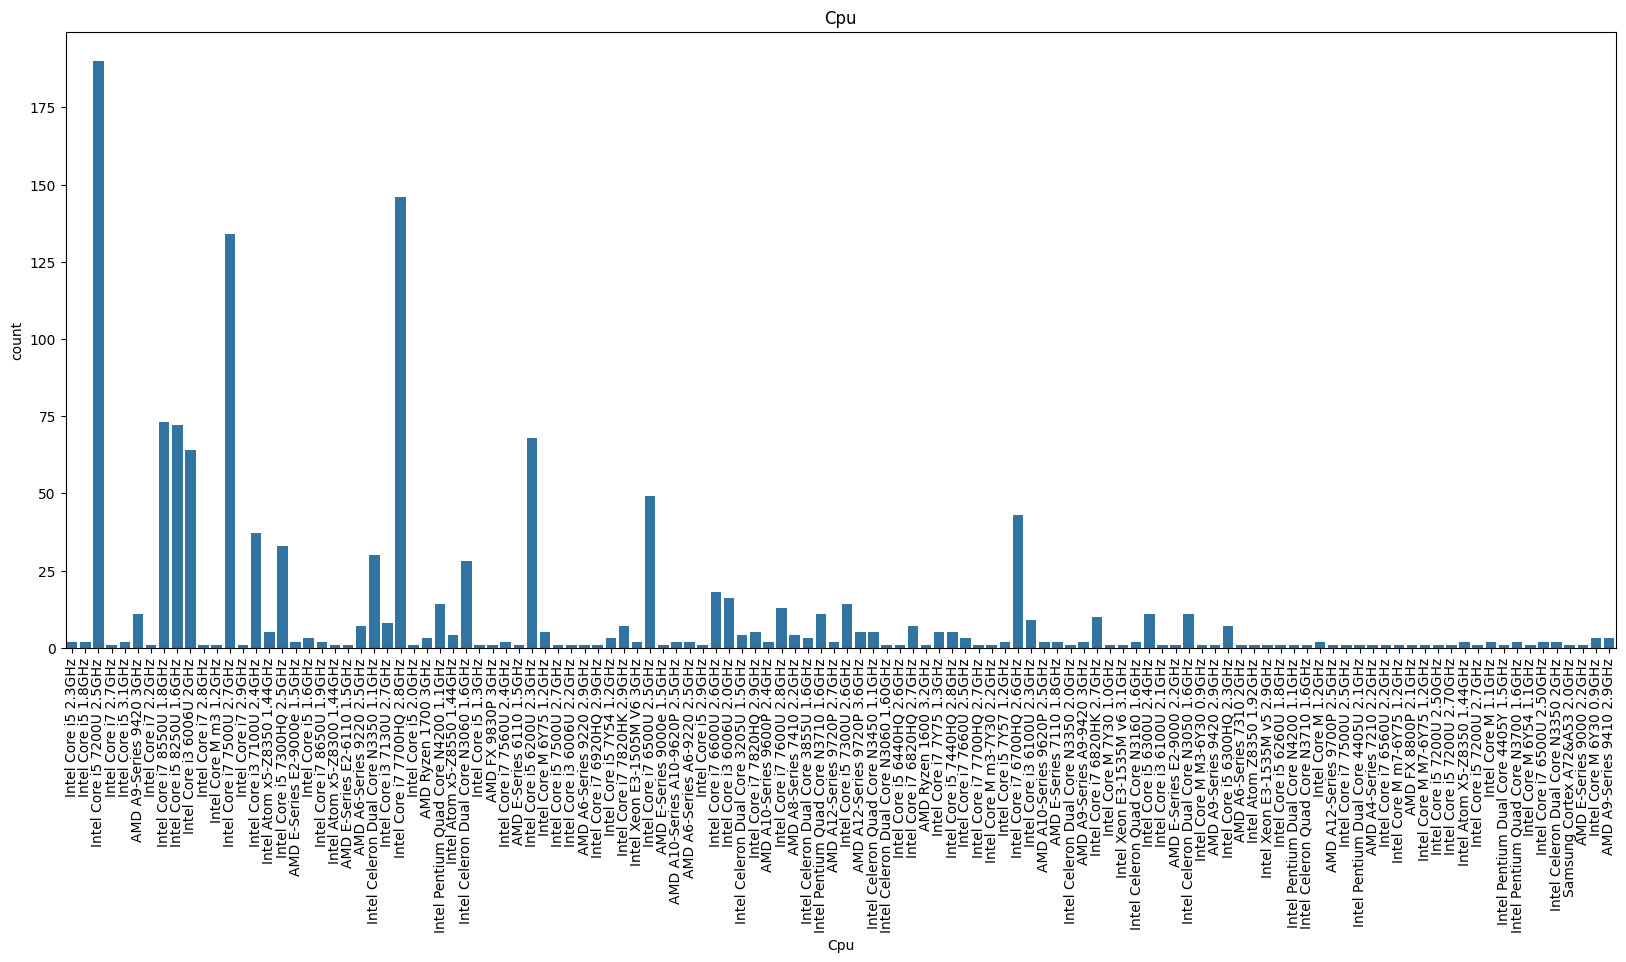

In [44]:
plt.figure(figsize=(20,8))
sns.countplot(x="Cpu", data=df)
plt.title("Cpu")
plt.xticks(rotation=90)
plt.show()

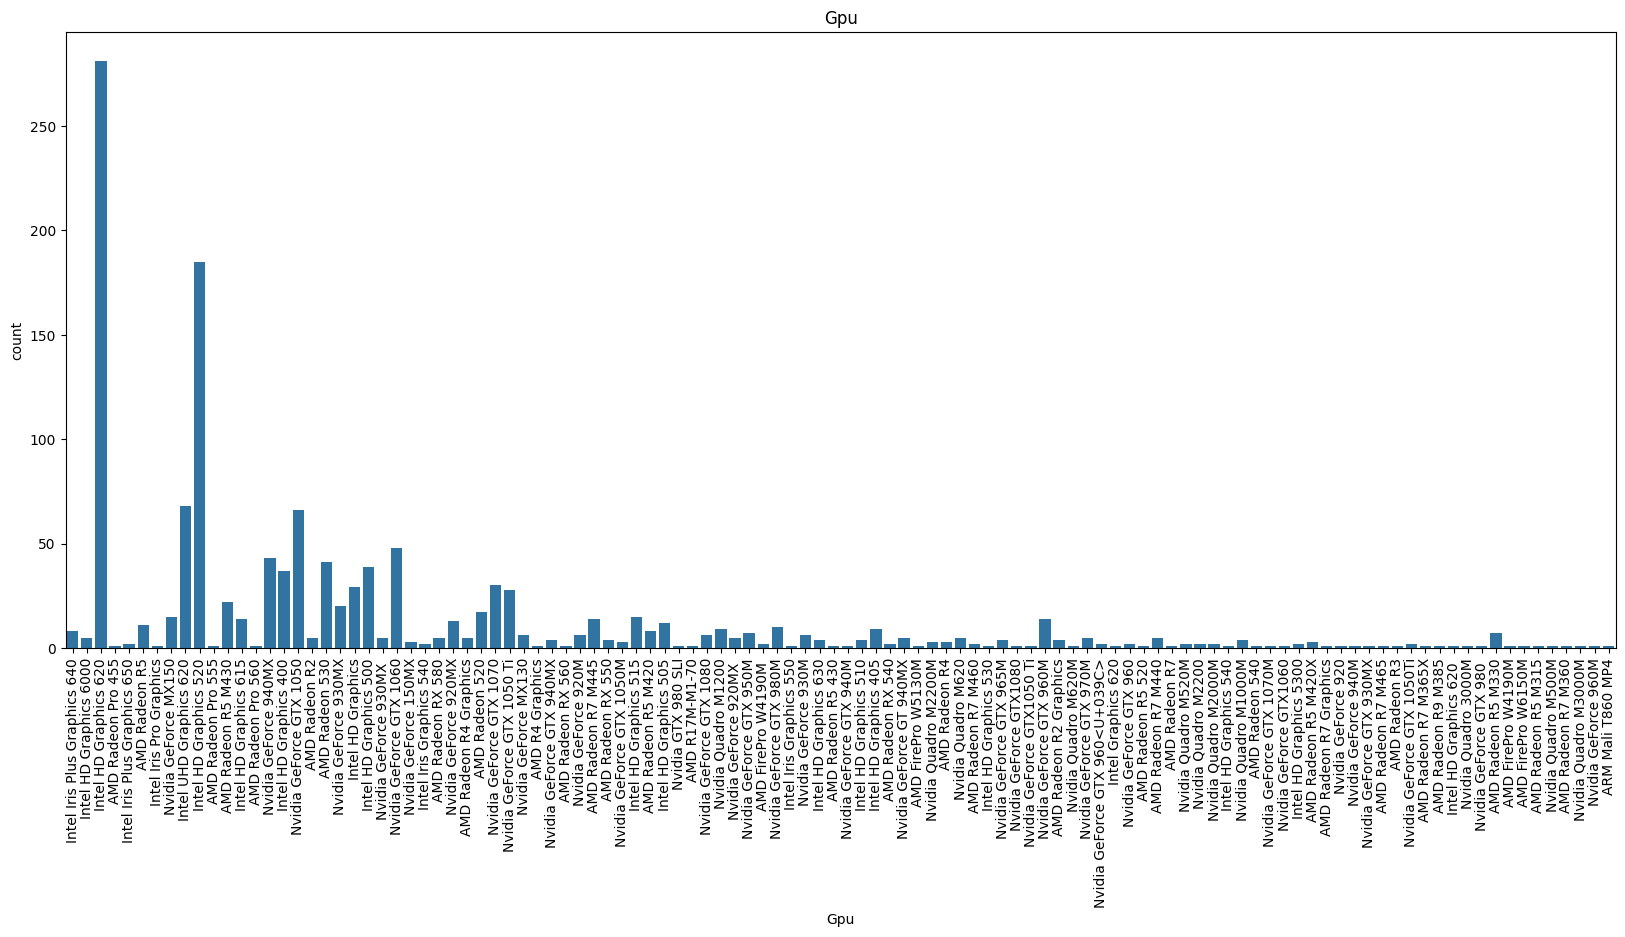

In [45]:
plt.figure(figsize=(20,8))
sns.countplot(x="Gpu", data=df)
plt.title("Gpu")
plt.xticks(rotation=90)
plt.show()

# Correlation Heatmap

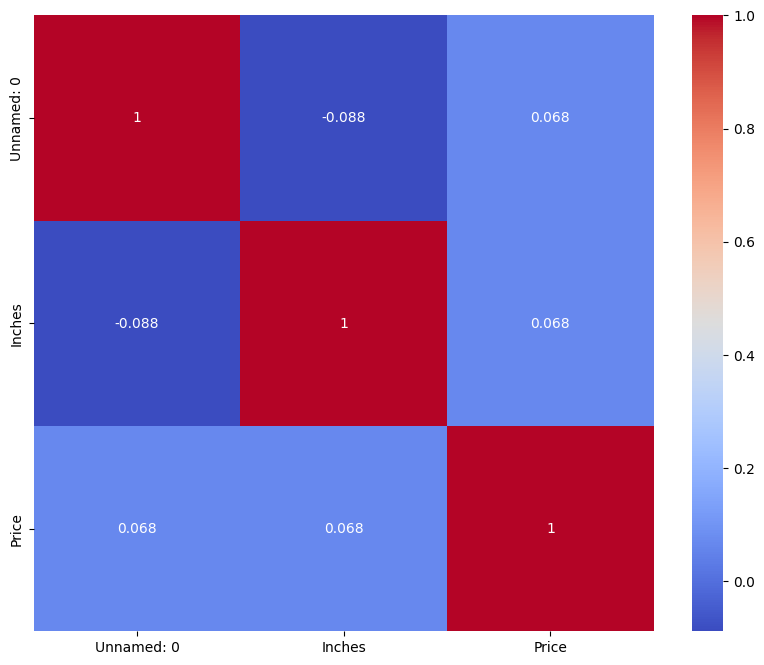

In [51]:
numeric_df=df.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(),annot=True,cmap='coolwarm')
plt.show()

In [54]:
X = df.drop('Price', axis=1)
y = df['Price']

print("Independent Features:")
print(X.columns)
print("\nDependent Feature:")
print(y.name)

# Reason:
# 'price' is the target variable to be predicted.
# All remaining columns are used as input features.

Independent Features:
Index(['Unnamed: 0', 'Company', 'TypeName', 'Inches', 'ScreenResolution',
       'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight'],
      dtype='object')

Dependent Feature:
Price


In [56]:
# Before encoding
print(df[['Company','TypeName']].head())
# One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=['Company','TypeName'], drop_first=True)
# After encoding
print(df_encoded.head())

  Company   TypeName
0   Apple  Ultrabook
1   Apple  Ultrabook
2      HP   Notebook
3   Apple  Ultrabook
4   Apple  Ultrabook
   Unnamed: 0  Inches                    ScreenResolution  \
0           0    13.3  IPS Panel Retina Display 2560x1600   
1           1    13.3                            1440x900   
2           2    15.6                   Full HD 1920x1080   
3           3    15.4  IPS Panel Retina Display 2880x1800   
4           4    13.3  IPS Panel Retina Display 2560x1600   

                          Cpu   Ram               Memory  \
0        Intel Core i5 2.3GHz   8GB            128GB SSD   
1        Intel Core i5 1.8GHz   8GB  128GB Flash Storage   
2  Intel Core i5 7200U 2.5GHz   8GB            256GB SSD   
3        Intel Core i7 2.7GHz  16GB            512GB SSD   
4        Intel Core i5 3.1GHz   8GB            256GB SSD   

                            Gpu  OpSys  Weight        Price  ...  \
0  Intel Iris Plus Graphics 640  macOS  1.37kg   71378.6832  ...   
1        I

In [57]:
from sklearn.preprocessing import StandardScaler
X = df_encoded.drop('Price', axis=1)
# Scale only numeric columns
num_cols = X.select_dtypes(include=['int64','float64']).columns

scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

print(X.head())

   Unnamed: 0    Inches                    ScreenResolution  \
0   -1.730722 -1.204407  IPS Panel Retina Display 2560x1600   
1   -1.728063 -1.204407                            1440x900   
2   -1.725405  0.408772                   Full HD 1920x1080   
3   -1.722746  0.268495  IPS Panel Retina Display 2880x1800   
4   -1.720088 -1.204407  IPS Panel Retina Display 2560x1600   

                          Cpu   Ram               Memory  \
0        Intel Core i5 2.3GHz   8GB            128GB SSD   
1        Intel Core i5 1.8GHz   8GB  128GB Flash Storage   
2  Intel Core i5 7200U 2.5GHz   8GB            256GB SSD   
3        Intel Core i7 2.7GHz  16GB            512GB SSD   
4        Intel Core i5 3.1GHz   8GB            256GB SSD   

                            Gpu  OpSys  Weight  Company_Apple  ...  \
0  Intel Iris Plus Graphics 640  macOS  1.37kg           True  ...   
1        Intel HD Graphics 6000  macOS  1.34kg           True  ...   
2         Intel HD Graphics 620  No OS  1.86kg    